## Install additional packages (uncomment if needed)

In [1]:
# !conda install -y xlrd
# !conda install -y conda-forge::xgboost

## Import packages

In [17]:
import os
import locale
import calendar
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error as rmse
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel, polynomial_kernel
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

## Global variables

In [18]:
DATA_PATH = os.path.join(".")
FN = os.path.join(DATA_PATH, "all_data.xlsx")

# Load and process data

In [19]:
if os.path.isfile(FN):
    all_data = pd.read_excel(FN, index_col="date")
else:
    locale.setlocale(locale.LC_ALL, 'de_de')
    months = calendar.month_name[1:13]
    locale.setlocale(locale.LC_ALL, 'en_us')
    files = os.listdir(DATA_PATH)
    data_files = list(filter(lambda x: x.startswith("Verkauf"), files))
    data_files.sort()
    dataframes = []
    for file in data_files:
        for m in range(0, 12):
            data = pd.read_excel(file, header=5, skiprows=[6], sheet_name = months[m])
            wetter_name = [col for col in data.columns.values  if col.startswith("Wetter")][0]  # fix inconsistent column labels
            bemerkung_name = [col for col in data.columns.values  if col.startswith("Bemerkung")][0]  # fix inconsistent column labels
            data.rename(columns={wetter_name: "Wetter", bemerkung_name: "Bemerkung", 'Datum': "Wochentag", 'Unnamed: 1': 'day'}, inplace=True)
            data = data[pd.to_numeric(data["day"], errors='coerce').notnull()]  # no of rows not always the same; drop non-numeric values
            data["month"] = m + 1
            data["year"] = file.split(".")[0][-4:]
            data["date"] = pd.to_datetime(data[["day", "month", "year"]])
            data.set_index("date", inplace=True)        
            data = data[["MUSEUM", "Wochentag", "Bemerkung", "month", "year"]]            
            dataframes.append(data)
    all_data = pd.concat(dataframes)
    ferien = pd.read_excel("Ferien und Feiertage LU 1.xlsx", sheet_name="Ferien LU")
    all_data.loc[:, "FerienDummy"] = 0
    all_data.loc[:, "Ferien"] = "Nein"
    for col in range(1, 11, 2):
        name = ferien.columns.values[col]
        all_data.loc[:, name] = 0        
        for row in range(1, 17):
            start = ferien.iloc[row, col]
            stop = ferien.iloc[row, col+1]
            all_data.loc[start:stop, name] = 1
            all_data.loc[start:stop, "FerienDummy"] = 1
            all_data.loc[start:stop, "Ferien"] = name
    feiertage = pd.read_excel("Ferien und Feiertage LU 1.xlsx", sheet_name="Feiertage LU")
    all_data.loc[:, "Feiertag"] = "Nein"
    all_data.loc[:, "FeiertagDummy"] = 0    
    for row in range(1, 23):
        name = feiertage.iloc[row, 0]
        all_data.loc[:, name] = 0        
        for col in range(1, 30, 2):
            year = feiertage.columns.values[col]
            date = feiertage.iloc[row, col+1]
            day, month, _ = date.split(".")
            dt = datetime(year=year, day=int(day), month=int(month))
            all_data.loc[dt, name] = 1
            all_data.loc[dt, "Feiertag"] = name
            
            if not name in ['Fasnachtsdienstag', 'Fasnachtsmontag ', 'Muttertag', 'Schmutziger Donnerstag', 'Tag der Arbeit']:                
                all_data.loc[dt, "FeiertagDummy"] = 1            
    all_data = all_data.loc[~(all_data.MUSEUM==0)]  # remove COVID and end of sample
    all_data.loc[datetime(year=2010, month=10, day=31), "MUSEUM"] = 11000 + 8200 + 1800  # Datenfehler
    all_data.loc[datetime(year=2011, month=10, day=30), "MUSEUM"] = 11488 + 8495 + 10  # Datenfehler
    all_data["Marathon"]=all_data.Bemerkung.str.contains("Marathon", na=False)
    all_data.loc[datetime(year=2016, month=10, day=30), "Marathon"] = True  # Datenfehler 
    all_data["Museumstag"] = all_data.Bemerkung.str.contains("Museumstag", na=False)
    all_data["Museumsnacht"] = all_data.Bemerkung.str.contains("Museumsnacht", na=False)
    all_data.loc[datetime(year=2012, month=9, day=7), "Museumsnacht"] = False  # Datenfehler    
    all_data["Wochentag"] = all_data.index.day_name() # remove inconsistencies in day naming
    all_data["MUSEUM_lag"] = all_data["MUSEUM"].shift(1)
    all_data = all_data.iloc[1:, :]  # b/c of shift
    all_data["week"] = all_data.index.isocalendar().week
    all_data.drop("Bemerkung", axis=1, inplace=True)
    all_data = all_data.astype({'MUSEUM': 'Float64', "MUSEUM_lag": 'Float64', 'Marathon': 'int32',
                            'Museumstag': 'int32', 'Museumsnacht': 'int32', 'week': 'int32',
                           })
    weather_lucerne = pd.read_excel(os.path.join(DATA_PATH, "weather_lucerne.xlsx"), index_col="datetime", parse_dates=True)
    weather_lucerne.drop(["name", "precipprob", "snow", "snowdepth", "visibility",
                          "severerisk", "sunrise", "sunset", "moonphase", "description", "icon", "stations"], axis=1, inplace=True)
    all_data = all_data.join(weather_lucerne)    
    all_data.preciptype = all_data.preciptype.fillna("Clear")
    all_data.windgust = all_data.windgust.ffill()
    weather_zurich = pd.read_excel(os.path.join(DATA_PATH, "weather_zurich.xlsx"), index_col="datetime", parse_dates=True)
    weather_lugano = pd.read_excel(os.path.join(DATA_PATH, "weather_lugano.xlsx"), index_col="datetime", parse_dates=True)
    all_data["foen"] = weather_lugano.sealevelpressure - weather_zurich.sealevelpressure
    all_data.foen = all_data.foen.ffill()
    weather_pilatus = pd.read_excel(os.path.join(DATA_PATH, "weather_pilatus.xlsx"), index_col="datetime", parse_dates=True)
    weather_pilatus.drop(["name", "precipprob", "snow", "snowdepth", "visibility",
                          "severerisk", "sunrise", "sunset", "moonphase", "description", "icon", "stations", "sealevelpressure"], axis=1, inplace=True)
    weather_pilatus.preciptype = weather_pilatus.preciptype.fillna("Clear")
    weather_pilatus.windgust = weather_pilatus.windgust.ffill()
    all_data = all_data.join(weather_pilatus, rsuffix="_p")    
    all_data.to_excel(FN)
categorical_columns = [
                       "Wochentag", "Ferien", "Feiertag", 
                       "preciptype", "conditions", "month", "week", "uvindex",
                       "preciptype_p", "conditions_p", "uvindex_p",
                      ]
all_data[categorical_columns] = all_data[categorical_columns].astype("category") # needed for detecting categorical variables below

## Explore data

3274.0

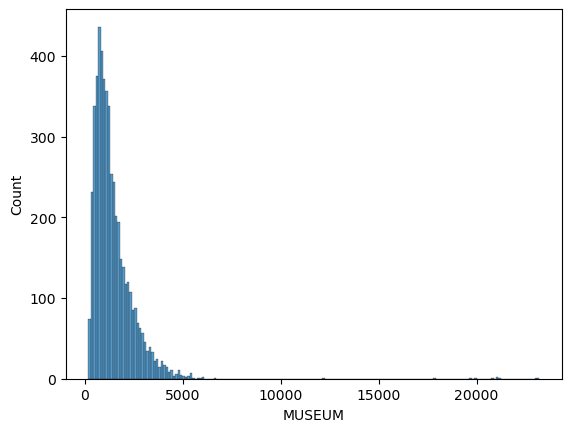

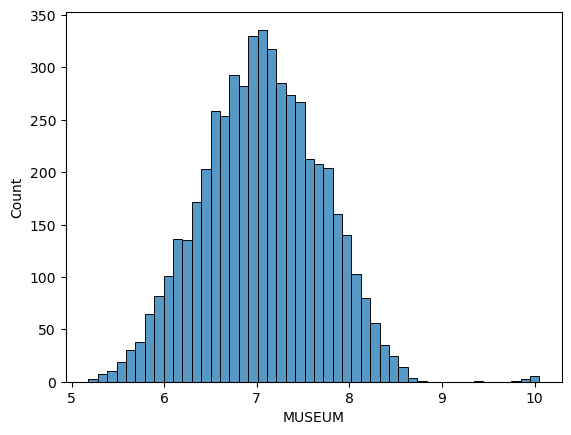

In [46]:
sns.histplot(all_data.MUSEUM)
plt.figure()
sns.histplot(np.log(all_data.MUSEUM));
all_data.MUSEUM.quantile(.95)

We'll work with the logs, obviously
## Fit a linear regression as baseline

In [6]:
mod = smf.ols(formula="""
        np.log(MUSEUM) ~ np.log(MUSEUM_lag) + 
        temp + feelslikemax + feelslikemin + feelslike + dew + humidity + precip + precipcover + windgust + windspeed + cloudcover + solarenergy +
        temp_p + dew_p + humidity_p + windgust_p + solarenergy_p +
        C(Feiertag, Treatment(reference='Nein')) + C(Wochentag, Treatment(reference='Monday')) + C(Ferien, Treatment(reference='Nein')) + C(week) +
        Marathon + Museumstag + Museumsnacht
    """ , data=all_data)
res = mod.fit()
pred = res.predict()
print("RSME", rmse(np.log(all_data.MUSEUM), pred))  # for comparison later, as a sanity check on sklearn
print(res.summary())

RSME 0.32703117006259763
                            OLS Regression Results                            
Dep. Variable:         np.log(MUSEUM)   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     136.3
Date:                Wed, 25 Sep 2024   Prob (F-statistic):               0.00
Time:                        16:37:03   Log-Likelihood:                -1551.7
No. Observations:                5151   AIC:                             3315.
Df Residuals:                    5045   BIC:                             4009.
Df Model:                         105                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

## Prepare data for sklearn

In [7]:
y = np.log(all_data["MUSEUM"]).copy()
X = all_data[["MUSEUM_lag", "temp", "feelslikemax", "feelslikemin", "feelslike", "dew", "humidity", "precip", "precipcover",
              "windgust", "windspeed", "cloudcover", "solarenergy",
              "temp_p", "dew_p", "humidity_p", "windgust_p",  "solarenergy_p",
              "Feiertag", "FerienDummy", "Wochentag", "Ferien", "week", "Marathon", "Museumstag", "Museumsnacht"
        ]].copy()
#X["FW"] = all_data["Wochentag"]
#X["FW"] = X.FW.astype("object")
#X.loc[X.FerienDummy==0, "FW"] = "No"
#X["FW"] = X.FW.astype("category")
X["log_MUSEUM_lag"] = np.log(X["MUSEUM_lag"])
X.drop(["MUSEUM_lag", "FerienDummy"], axis=1, inplace=True)

## Define and evaluate alternative models.

In [20]:
one_hot_encoder = make_column_transformer(
    (
        OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
        make_column_selector(dtype_include="category"),
    ),
    remainder="passthrough",
)
reg = make_pipeline(
    one_hot_encoder, StandardScaler(), LinearRegression()  # scaler isn't really needed here, estimator is invariant
)
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR()
)
knn = make_pipeline(
    one_hot_encoder, StandardScaler(), KNeighborsRegressor()
)
hgb = HistGradientBoostingRegressor(random_state=42, categorical_features="from_dtype")
xgb = XGBRegressor(enable_categorical=True)
models = ["reg", "knn", "svr", "hgb", "xgb"]



In [9]:
for modname in models:
    print(modname)
    mod = eval(modname)
    res = mod.fit(X, y)
    ypred = res.predict(X)
    print("RMSE", rmse(y, ypred))
    print("R2", r2_score(y, ypred))
    print("RMSE CV", -cross_val_score(mod, X, y, cv=5, scoring="neg_root_mean_squared_error"))
    print("R2 CV", cross_val_score(mod, X, y, cv=5, scoring="r2"))
    print()

reg
RMSE 0.3271778693545414
R2 0.7391821810615848
RMSE CV [0.34878786 0.34808006 0.32494726 0.35680914 0.32221807]
R2 CV [0.70277151 0.70902895 0.74614559 0.7048801  0.71799656]

knn
RMSE 0.26254691111208833
R2 0.8320487481045318
RMSE CV [0.34761062 0.33019261 0.30680235 0.37352617 0.32951369]
R2 CV [0.70477455 0.73816591 0.7737043  0.6765787  0.70508181]

svr
RMSE 0.20125252300649338
R2 0.9013147862015629
RMSE CV [0.27192531 0.27631392 0.25491955 0.30114927 0.25634765]
R2 CV [0.81933793 0.8166432  0.84376971 0.78977218 0.82151024]

hgb
RMSE 0.16979132033870462
R2 0.9297574304503424
RMSE CV [0.28915912 0.28062673 0.27360277 0.31182888 0.26597212]
R2 CV [0.79571263 0.81087472 0.82003008 0.77459725 0.80785598]

xgb
RMSE 0.0675463210330328
R2 0.9888833785081483
RMSE CV [0.2884252  0.29194876 0.27805121 0.31777893 0.27124872]
R2 CV [0.79674832 0.79530616 0.81413032 0.76591329 0.8001565 ]



RMSE of linear model agrees with statsmodels above. SVR seems preferred.

## Tune parameters
### KNN

In [10]:
res = GridSearchCV(
        knn,
        param_grid={'kneighborsregressor__n_neighbors': range(1,12)
                   },
        cv=5,
        scoring="r2",
        refit=True,
        n_jobs=-1,    
).fit(X, y)

In [11]:
res.best_score_

0.7196610523235079

In [12]:
res.best_params_

{'kneighborsregressor__n_neighbors': 5}

### SVR

In [13]:
res = GridSearchCV(
        svr,
        param_grid={'svr__gamma': ['auto'],
                    'svr__C': [1, 1.1, 1.2, 1.3, 1.4, 1.5],
                    'svr__epsilon': [0.09, 0.1, 1.1],
                    'svr__kernel': ["rbf"]
                   },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)

KeyboardInterrupt: 

In [ ]:
res.best_score_

In [ ]:
res.best_params_

In [ ]:
res = GridSearchCV(
        svr,
        param_grid={'svr__gamma': ['auto'],
                    'svr__C': [1.22, 1.24, 1.26, 1.28, 1.3, 1.32, 1.34, 1.36, 1.38, 1.4],
                    'svr__epsilon': [0.095, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2],
                    'svr__kernel': ["rbf", "poly"],
                    'svr__degree': [3],
                   },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)

In [ ]:
res.best_score_

In [ ]:
res.best_params_

### XGBoost

In [ ]:
import time
start = time.time()
res = GridSearchCV(
        xgb,
        param_grid = {
            'min_child_weight': [0.5, 1, 2],
            'gamma': [0, 0.25, 0.5],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.4, 0.6, 0.8],
            'max_depth': [2, 3, 4, 5],
            'learning_rate': [0.05, 0.1, 0.2],
            'reg_lambda': [0, 0.1, 0.2],
            'reg_alpha': [0.5, 1.0, 1.5],
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)
end = time.time()
print(end - start)

In [ ]:
res.best_score_

In [ ]:
res.best_params_

In [ ]:
import time
start = time.time()
res = GridSearchCV(
        xgb,
        param_grid = {
            'min_child_weight': [.3, .5, .7],
            'gamma': [0, 0.1],
            'subsample': [0.7, 0.8, .9],
            'colsample_bytree': [0.5, 0.6, 0.7],
            'max_depth': [5, 6, 7],
            'learning_rate': [0.075, 0.1, 0.125],
            'reg_lambda': [0, 0.1],
            'reg_alpha': [0.4, 0.5, 0.6],
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)
end = time.time()
print(end - start)

In [ ]:
res.best_score_

In [ ]:
res.best_params_

In [ ]:
import time
start = time.time()
res = GridSearchCV(
        xgb,
        param_grid = {
            'min_child_weight': [.1, .2, .3, .4],
            'gamma': [0, 0.05, 0.1, .2],
            'subsample': [0.75, 0.8, .85],
            'colsample_bytree': [0.55, 0.6, 0.65],
            'max_depth': [5],
            'learning_rate': [0.09, 0.1, 0.11],
            'reg_lambda': [0, 0.05],
            'reg_alpha': [0.1, 0.2, 0.3, 0.4, 0.5],
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)
end = time.time()
print(end - start)

In [ ]:
res.best_score_

In [ ]:
res.best_params_

In [ ]:
import time
start = time.time()
res = GridSearchCV(
        xgb,
        param_grid = {
            'min_child_weight': [.001, .01, .02],
            'gamma': [0.08, 0.1, .12],
           'subsample': [0.8],
           'colsample_bytree': [0.6],
            'max_depth': [5],
            'learning_rate': [0.1, 0.11, .12],
            'reg_lambda': [0, 0.01],
            'reg_alpha': [0.1, 0.15, 0.2, 0.25, 0.3],
            "n_estimators": [100, 200, 300]
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)
end = time.time()
print(end - start)

In [ ]:
res.best_score_

In [ ]:
res.best_params_

In [ ]:
import time
start = time.time()
res = GridSearchCV(
        xgb,
        param_grid = {
            'min_child_weight': [0, .001],
            'gamma': [0.1],
           'subsample': [0.8],
           'colsample_bytree': [0.6],
            'max_depth': [5, 6],
            'learning_rate': [0.11],
            'reg_lambda': [0],
            'reg_alpha': [.18, 0.2, .22],
            "n_estimators": [400, 500, 600]
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)
end = time.time()
print(end - start)

In [ ]:
res.best_score_

In [ ]:
res.best_params_

## Compare final models

In [ ]:
X_train = X.loc[:'01.01.2023', :]
X_test = X.loc['01.01.2023':, :]
y_train = y.loc[:'01.01.2023']
y_test = y.loc['01.01.2023':]
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.28, gamma="auto")
).fit(X_train, y_train)
xgb = XGBRegressor(enable_categorical=True, **{'colsample_bytree': 0.6,
 'gamma': 0.1,
 'learning_rate': 0.11,
 'max_depth': 5,
 'min_child_weight': 0,
 'n_estimators': 500,
 'reg_alpha': 0.2,
 'reg_lambda': 0,
 'subsample': 0.8}).fit(X_train, y_train)


In [ ]:
psvr = svr.predict(X_test)
pxgb = xgb.predict(X_test)

In [ ]:
rmse(np.exp(y_test), np.exp(psvr))

In [ ]:
rmse(np.exp(y_test), np.exp(pxgb))

In [ ]:
all_data.loc["1.1.2023":, "pred"] = np.exp(psvr)

In [ ]:
all_data.loc["1.1.2023":, ["MUSEUM", "pred"]].plot()

## Select features


In [9]:
y = np.log(all_data["MUSEUM"]).copy()
X = all_data[["MUSEUM_lag", "temp", "feelslikemax", "feelslikemin", "feelslike", "dew", "humidity", "precip", "precipcover",
              "windgust", "windspeed", "cloudcover", "solarenergy",
              "temp_p", "dew_p", "humidity_p", "windgust_p",  "solarenergy_p",
              "Feiertag", "FerienDummy", "Wochentag", "Ferien", "week", "Marathon", "Museumstag", "Museumsnacht"
        ]].copy()
#X["FW"] = all_data["Wochentag"]
#X["FW"] = X.FW.astype("object")
#X.loc[X.FerienDummy==0, "FW"] = "No"
#X["FW"] = X.FW.astype("category")
X["log_MUSEUM_lag"] = np.log(X["MUSEUM_lag"])
X.drop(["MUSEUM_lag", "FerienDummy"], axis=1, inplace=True)
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.28, gamma="auto")
)
res = svr.fit(X, y)
ypred = res.predict(X)
print("RMSE", rmse(y, ypred))
print("R2", r2_score(y, ypred))
print("RMSE", rmse(np.exp(y), np.exp(ypred)))
print("R2", r2_score(np.exp(y), np.exp(ypred)))
print("RMSE CV", -cross_val_score(svr, X, y, cv=5, scoring="neg_root_mean_squared_error"))
print("R2 CV", cross_val_score(svr, X, y, cv=5, scoring="r2"))
print()

RMSE 0.1948008268191448
R2 0.907540612765313
RMSE 331.6938214713301
R2 0.9270005534564121
RMSE CV [0.27016496 0.2749974  0.25553136 0.30129343 0.25647355]
R2 CV [0.82166944 0.81838628 0.8430189  0.78957086 0.82133487]



In [14]:
y = np.log(all_data["MUSEUM"]).copy()
X = all_data[["MUSEUM_lag", "temp", "feelslikemax", "feelslikemin", "feelslike", "dew", "humidity", "precip", "precipcover",
              "windgust", "windspeed", "cloudcover", "solarenergy",
              "temp_p", "dew_p", "humidity_p", "windgust_p",  "solarenergy_p",
              "Feiertag", "FerienDummy", "Wochentag", "Ferien", "week", "Marathon", "Museumstag", "Museumsnacht"
        ]].copy()
#X["FW"] = all_data["Wochentag"]
#X["FW"] = X.FW.astype("object")
#X.loc[X.FerienDummy==0, "FW"] = "No"
#X["FW"] = X.FW.astype("category")
X["log_MUSEUM_lag"] = np.log(X["MUSEUM_lag"])
X.drop(["MUSEUM_lag", "FerienDummy"], axis=1, inplace=True)
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.28, gamma="auto")
)
res = svr.fit(X, y)
ypred = res.predict(X)
print("RMSE", rmse(y, ypred))
print("R2", r2_score(y, ypred))
print("RMSE", rmse(np.exp(y), np.exp(ypred)))
print("R2", r2_score(np.exp(y), np.exp(ypred)))
print("RMSE CV", -cross_val_score(svr, X, y, cv=5, scoring="neg_root_mean_squared_error"))
print("R2 CV", cross_val_score(svr, X, y, cv=5, scoring="r2"))
print()

RMSE 0.1948008268191448
R2 0.907540612765313
RMSE 331.6938214713301
R2 0.9270005534564121
RMSE CV [0.27016496 0.2749974  0.25553136 0.30129343 0.25647355]
R2 CV [0.82166944 0.81838628 0.8430189  0.78957086 0.82133487]



# Final Model

In [16]:

y = np.log(all_data["MUSEUM"]).copy()
X = all_data[["MUSEUM_lag",              
              "tempmax",   "temp", "feelslikemax", "feelslikemin", "feelslike", "dew", "humidity", "precip", "solarradiation",                
              "tempmax_p", "temp_p", "tempmin_p", "feelslikemax_p", "feelslikemin_p", "humidity_p", "windgust_p", "solarenergy_p", "solarradiation_p",
              "Feiertag",
              "Wochentag",
              "Ferien",
              "week",
              "Marathon",
              "Museumstag",
              "Museumsnacht"
        ]].copy()
X["log_MUSEUM_lag"] = np.log(X["MUSEUM_lag"])
X.drop(["MUSEUM_lag"], axis=1, inplace=True)
#X.Feiertag = X.Feiertag.cat.remove_categories("Schmutziger Donnerstag").fillna("Nein")
#X.Feiertag = X.Feiertag.cat.remove_categories("Fasnachtsmontag").fillna("Nein")
#X.Feiertag = X.Feiertag.cat.remove_categories("Ostern").fillna("Nein")
X.Feiertag = X.Feiertag.cat.remove_categories("Mariä¤ Himmelfahrt").fillna("Nein")
X.Feiertag = X.Feiertag.cat.remove_categories("St. Leodegar").fillna("Nein")
X.Feiertag = X.Feiertag.cat.remove_categories("Neujahrstag").fillna("Nein")
#X.Feiertag = X.Feiertag.cat.remove_categories("Berchtoldstag").fillna("Nein")
X.Feiertag = X.Feiertag.cat.add_categories("Heiligabend")
X.loc[(X.Feiertag.index.month==12) & (X.Feiertag.index.day==24), "Feiertag"] = "Heiligabend"
X.Feiertag = X.Feiertag.cat.add_categories("ZDJ")  # zwischen den Jahren
X.loc[(X.Feiertag==12) & (X.Feiertag.index.day>=27) & (X.Feiertag.index.day<=30), "Feiertag"] = "ZDJ"
X.Feiertag = X.Feiertag.cat.add_categories("BT")  # Brückentag
X.loc[(all_data.FeiertagDummy.shift(1)==1) & (X.Wochentag == "Friday"),    "Feiertag"] = "BT"
X.loc[(all_data.FeiertagDummy.shift(-1)==1) & (X.Wochentag == "Monday"),    "Feiertag"] = "BT"
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.6, epsilon=0.08, gamma="auto")
)
res = svr.fit(X, y)
ypred = res.predict(X)
print("RMSE", rmse(y, ypred))
print("R2", r2_score(y, ypred))
print("RMSE", rmse(np.exp(y), np.exp(ypred)))
print("R2", r2_score(np.exp(y), np.exp(ypred)))
print("RMSE CV", np.mean(-cross_val_score(svr, X, y, cv=5, scoring="neg_root_mean_squared_error")))
print("R2 CV", np.mean(cross_val_score(svr, X, y, cv=5, scoring="r2")))
print()
#RMSE CV 0.2621562575983206
#R2 CV 0.831027897678639

RMSE 0.18901514611181777
R2 0.912951231428496
RMSE 312.31242451732567
R2 0.9352822623282757
RMSE CV 0.2621562575983206
R2 CV 0.831027897678639



# Final Model for Feasible Forecasts

In [27]:
y = np.log(all_data["MUSEUM"]).copy()
X = all_data[["tempmax",   "tempmin",   "temp",    "feelslike", "dew", "humidity",   "precip",                   "sealevelpressure", "cloudcover", 
              "tempmax_p", "tempmin_p", "temp_p",  "feelslike_p",      "humidity_p", "precip_p", "windgust_p", 
              "Feiertag",
              "Wochentag",
              "Ferien",
              "week",
              "Marathon",
              "Museumstag",
              "Museumsnacht"
        ]].copy()

X.Feiertag = X.Feiertag.cat.add_categories("Heiligabend")
X.loc[(X.Feiertag.index.month==12) & (X.Feiertag.index.day==24), "Feiertag"] = "Heiligabend"
X.Feiertag = X.Feiertag.cat.add_categories("BT")  # Brückentag
X.loc[(all_data.FeiertagDummy.shift(1)==1) & (X.Wochentag == "Friday") &  (all_data.FeiertagDummy==0),    "Feiertag"] = "BT"
X.loc[(all_data.FeiertagDummy.shift(-1)==1) & (X.Wochentag == "Monday") & (all_data.FeiertagDummy==0),    "Feiertag"] = "BT"

X.Feiertag = X.Feiertag.cat.add_categories("ZDJ")  # zwischen den Jahren
X.loc[(X.Feiertag.index.month==12) & (X.Feiertag.index.day>=27) & (X.Feiertag.index.day<=30), "Feiertag"] = "ZDJ"
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.7, epsilon=0.16, gamma="auto")
)
res = svr.fit(X, y)
ypred = res.predict(X)
print("RMSE", rmse(y, ypred))
print("R2", r2_score(y, ypred))
print("RMSE", rmse(np.exp(y), np.exp(ypred)))
print("R2", r2_score(np.exp(y), np.exp(ypred)))
print("RMSE CV", np.mean(-cross_val_score(svr, X, y, cv=5, scoring="neg_root_mean_squared_error")))
print("R2 CV", np.mean(cross_val_score(svr, X, y, cv=5, scoring="r2")))
print()
#RMSE CV 0.2769827859785941
#R2 CV 0.8108548831046022



RMSE 0.20323549686901318
R2 0.899360482421079
RMSE 335.1766778287057
R2 0.9254594852072385
RMSE CV 0.2769827859785941
R2 CV 0.8108548831046022



In [25]:
pd.DataFrame(np.exp(res.predict(X["1/2/2023":"12/31/2023"]))).to_excel("pred.xlsx")

In [29]:
x_raw = X["7/31/2023":"7/31/2023"]
x_onehot = one_hot_encoder.transform(x_raw)
x = res[1].transform(x_onehot)
pd.DataFrame(x).to_excel("x_new.xlsx")
pd.DataFrame(x_onehot).to_excel("x_onehot_new.xlsx")
pd.DataFrame(x_raw).to_excel("x_raw_new.xlsx")
support_vectors = res[2].support_vectors_
dual_coefs = res[2].dual_coef_[0]
nsv, nf = support_vectors.shape
intercept = res[2].intercept_
gamma = 1/ nf
print(intercept[0], gamma)
vrbf = support_vectors - x

pred1 = np.matmul(dual_coefs, rbf_kernel(support_vectors, Y=x, gamma=gamma)) + intercept
pred2 = np.matmul(dual_coefs, np.diag(np.exp(-gamma * np.matmul(vrbf, vrbf.T)))) + intercept
pred3 = np.sum(dual_coefs * np.exp(-gamma * np.sum(vrbf ** 2, axis=1))) + intercept
print(pred1, pred2, pred3, res.predict(x_raw))

np.exp(pred1)

7.419932029435034 0.009009009009009009
[7.49914606] [7.49914606] [7.49914606] [7.49914606]


array([1806.49910927])

In [22]:
res = GridSearchCV(
        svr,
        param_grid={'svr__gamma': ['auto'],
                    'svr__C': [1.6, 1.7, 1.8],
                    'svr__epsilon': [0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16],
                    'svr__kernel': ["rbf"]
                   },
        cv=5,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,    
).fit(X, y)

In [23]:
res.best_score_

-0.2769827859785941

In [24]:
res.best_params_

{'svr__C': 1.7,
 'svr__epsilon': 0.16,
 'svr__gamma': 'auto',
 'svr__kernel': 'rbf'}

In [18]:
#https://stackoverflow.com/questions/75385861/how-does-a-trained-svr-model-predict-values
res = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.7, epsilon=0.16, gamma="auto")
).fit(X, y)
x_raw = X.iloc[-1:, :]
x = one_hot_encoder.transform(x_raw)
x = res[1].transform(x)
support_vectors = res[2].support_vectors_
dual_coefs = res[2].dual_coef_[0]
nsv, nf = support_vectors.shape
intercept = res[2].intercept_
gamma = 1/ nf
vrbf = support_vectors - x

pred1 = np.matmul(dual_coefs, rbf_kernel(support_vectors, Y=x, gamma=gamma)) + intercept
pred2 = np.matmul(dual_coefs, np.diag(np.exp(-gamma * np.matmul(vrbf, vrbf.T)))) + intercept
pred3 = np.sum(dual_coefs * np.exp(-gamma * np.sum(vrbf ** 2, axis=1))) + intercept
print(pred1, pred2, pred3, res.predict(x_raw))

np.exp(pred1)
print(svr.predict(x_raw))
print(intercept[0])
gamma


[7.25824791] [7.25824791] [7.25824791] [7.25824791]
[7.25824791]
7.422430417811894


0.009009009009009009

In [20]:
one_hot_encoder.get_feature_names_out()

array(['onehotencoder__Feiertag_Allerheiligen',
       'onehotencoder__Feiertag_Auffahrt', 'onehotencoder__Feiertag_BT',
       'onehotencoder__Feiertag_Berchtoldstag\xa0',
       'onehotencoder__Feiertag_Fasnachtsdienstag',
       'onehotencoder__Feiertag_Fasnachtsmontag\xa0',
       'onehotencoder__Feiertag_Fronleichnam',
       'onehotencoder__Feiertag_Heiligabend',
       'onehotencoder__Feiertag_Karfreitag',
       'onehotencoder__Feiertag_Mariä¤ Empfängnis',
       'onehotencoder__Feiertag_Mariä¤ Himmelfahrt',
       'onehotencoder__Feiertag_Muttertag',
       'onehotencoder__Feiertag_Nationalfeiertag Schweiz',
       'onehotencoder__Feiertag_Nein',
       'onehotencoder__Feiertag_Neujahrstag',
       'onehotencoder__Feiertag_Ostermontag',
       'onehotencoder__Feiertag_Ostern',
       'onehotencoder__Feiertag_Pfingsten',
       'onehotencoder__Feiertag_Pfingstmontag',
       'onehotencoder__Feiertag_Schmutziger Donnerstag',
       'onehotencoder__Feiertag_Silvester',
       'on

In [30]:
pd.DataFrame(support_vectors).to_excel("supportvectors.xlsx")
pd.DataFrame(x).to_excel("x.xlsx")
pd.DataFrame(x_raw).to_excel("x_raw.xlsx")
pd.DataFrame(dual_coefs).to_excel("dualcoefs.xlsx")
means = res[1].mean_
std = res[1].scale_
pd.DataFrame(means, std).to_excel("ms.xlsx")
means[-1]

0.0011648223645894002

In [18]:
X_train = X.loc[:'01.01.2023', :]
y_train = y.loc[:'01.01.2023']
X_test = X.loc['01.01.2023':, :]
y_test = y.loc['01.01.2023':]
svr = make_pipeline(
    one_hot_encoder, StandardScaler(), SVR(C=1.7, epsilon=0.1, gamma="auto")
).fit(X_train, y_train)
y_pred = y_test.copy().to_frame(name='y_pred')
y_pred['y_pred'] = np.exp(svr.predict(X_test))
y_pred['y'] = np.exp(y_test)



RMSE 424.6059959296002
R2 0.8788303748873626


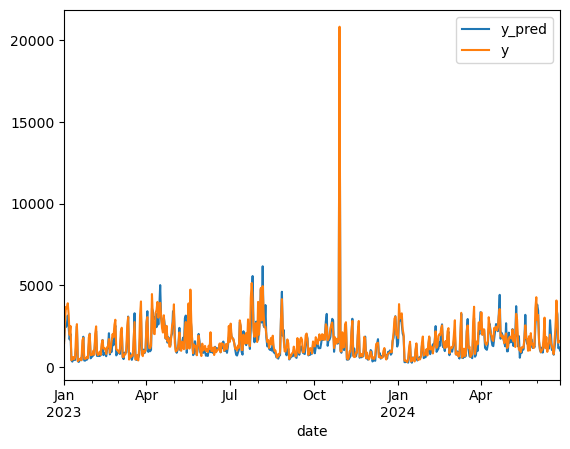

In [19]:
print("RMSE", rmse(y_pred['y'], y_pred['y_pred']))
print("R2", r2_score(y_pred['y'], y_pred['y_pred']))
y_pred.plot();
y_pred.to_excel("y_pred.xlsx")

In [ ]:
X.columns

In [34]:
x_raw

,tempmax,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,solarradiation,tempmax_p,...,solarenergy_p,solarradiation_p,Feiertag,Wochentag,Ferien,week,Marathon,Museumstag,Museumsnacht,log_MUSEUM_lag
date,,,,,,,,,,,,,,,,,,,,,
2024-06-26,23.9,18.8,23.9,14.7,18.8,15.1,80.1,0.2,310.6,18.5,...,27.0,310.6,Nein,Wednesday,Nein,26,0,0,0,7.370231


In [33]:
one_hot_encoder.transform(x_raw)


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

In [93]:
one_hot_encoder.transform(x_raw)[0][90:]

array([2.39000000e+01, 1.47000000e+01, 1.88000000e+01, 1.51000000e+01,
       8.01000000e+01, 2.00000000e-01, 3.10600000e+02, 1.85000000e+01,
       1.09000000e+01, 8.90000000e+00, 1.85000000e+01, 6.00000000e+00,
       8.28000000e+01, 5.94000000e+01, 2.70000000e+01, 3.10600000e+02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.37023064e+00])

In [55]:
X.[-1,:]

tempmax                  23.9
temp                     18.8
feelslikemax             23.9
feelslikemin             14.7
feelslike                18.8
dew                      15.1
humidity                 80.1
precip                    0.2
solarradiation          310.6
tempmax_p                18.5
temp_p                   10.9
tempmin_p                 8.9
feelslikemax_p           18.5
feelslikemin_p            6.0
humidity_p               82.8
windgust_p               59.4
solarenergy_p            27.0
solarradiation_p        310.6
Feiertag                 Nein
Wochentag           Wednesday
Ferien                   Nein
week                       26
Marathon                    0
Museumstag                  0
Museumsnacht                0
log_MUSEUM_lag       7.370231
Name: 2024-06-26 00:00:00, dtype: object

In [88]:
x

array([[-0.05220466, -0.05404221, -0.13633817, -0.05030077, -0.05220466,
        -0.02787744, -0.05404221, -0.04626098, -0.05220466, -0.05220466,
        -0.05220466, -0.05220466,  0.27082949, -0.05220466, -0.05220466,
        -0.05404221, -0.05404221, -0.04410382, -0.04626098, -0.04832271,
        -0.05220466, -0.04626098, -0.40829452, -0.40861808, -0.40829452,
        -0.40699919, -0.40829452, -0.40861808,  2.44727301, -0.22058185,
        -0.21371945,  0.68069984, -0.3688942 , -0.26792773, -0.20358692,
        -0.13926385, -0.13926385, -0.13926385, -0.13926385, -0.13926385,
        -0.13926385, -0.13926385, -0.13926385, -0.14425173, -0.14425173,
        -0.14284299, -0.13926385, -0.13926385, -0.13926385, -0.13926385,
        -0.13926385, -0.13926385, -0.13926385, -0.13926385, -0.14425173,
        -0.14425173, -0.14425173, -0.14425173, -0.14425173, -0.14425173,
         7.07106781, -0.13926385, -0.13926385, -0.13926385, -0.13926385,
        -0.13926385, -0.13926385, -0.13926385, -0.1